# Lorenz96
For a number of variables $ J \in \mathbb{N} $, external force $ F \in \mathbb{R} $ and state variable $ \mathbb{u} \in \mathbb{R}^J $ on 1D periodic domain, the Lorenz 96 equation (Lorenz 1996) is given by

$$ \frac {du^{i}}{dt} =(u^{i+1}-u^{i-2})u^{i-1}-u^{i}+F, $$

with $ u^{-1} = u^{J-1} $, $ u^0 = u^J $, and $ u^{J+1} = u^1 $.

## Partial observation
Let $ J = 3J' $ for $ J' \in \mathbb{N} $.

$$ P = [e_1, e_2, 0, e_4, e_5, 0, e_7, \dots, 0] \in \mathbb{R}^{J \times J}, $$

where $ (e_i)_{i=1}^J $ is a standard basis of $ \mathbb{R}^J $.

cf. K. J. H. Law, D. Sanz-Alonso, A. Shukla, and A. M. Stuart, Filter accuracy for the Lorenz 96 model: Fixed versus adaptive observation operators, Phys. Nonlinear Phenom., 325 (2016), pp. 1–13.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from da.l96 import lorenz96
from da.scheme import rk4
from da.visualize import plot_loss
from da.etkf import ETKF
from da.po import PO
import visualize
plt.rcParams['text.usetex'] = False # 場当たり的な対応

data_dir = "data/20241204v2"

In [3]:
# Lorenz96
# J: dim of state space
J = 60

# F: forcing
F = 8

print("(J, F):", (J, F))

(J, F): (60, 8)


## Generate the true trajectory

In [4]:
# generate data
# dt: time step size
dt = 0.01

# N: number of time steps, 2 years : 20*360*2 steps
N0 = 20*360 
N = 20*360

# initial state near the stationary point
x0 = F*np.ones(J) # the stationary point
x0[19] *= 1.001 # perturb

# use my modules
scheme = rk4
p = (F, )

try:
    x_true = np.load(f"{data_dir}/x_true_l96_full.npy")
    print("x_true loaded:", x_true.shape)
except:
    result = np.zeros((N0+N,len(x0)))
    x = x0
    result[0] = x[:]

    for n in range(1, N0+N):
        t = n*dt
        x = scheme(lorenz96, t, x, p, dt)
        result[n] = x[:]


    x_true = result[N0:] # spin up 1 year and save per 6 hours
    print(x_true.shape)
    np.save(f"{data_dir}/x_true_l96_full", x_true)

x_true loaded: (7200, 60)


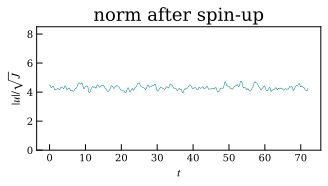

In [5]:
# norm (normalized energy)
norm = np.linalg.norm(x_true[:], axis=-1)/np.sqrt(J)
t = np.arange(N)*dt
fig3, ax3 = plt.subplots()
ax3.grid(False)
ax3.set_title('norm after spin-up')
ax3.set_xlabel('$t$')
ax3.set_ylabel('$ |u|/\\sqrt{J}$')
ax3.set_ylim([0.0, 8.5])
ax3.plot(t, norm, lw=0.5)
fig3.tight_layout()
# fig3.savefig(f"{data_dir}/l96_norm.pdf")

## DA setting

In [6]:
# observation interval
obs_per = 1
print("obs_per", obs_per, "steps")

# assimilation interval
Dt = dt * obs_per

# Model function for EnKF
def M(x, Dt):
    for i in range(obs_per):
        x = rk4(lorenz96, 0, x, p, dt)
    return x

# Observation operator
# H_diag = np.ones(J) # full

H_diag = np.ones(J) # partial 1
H_diag[2::3] = 0
H = np.diag(H_diag) # shape: (60, 60)
H = H[H_diag!=0] # shape: (40, 60)

Ny = np.linalg.matrix_rank(H)
print("H.shape:", H.shape)
print("diag of H:", H_diag)
print("rank(H):", Ny)

# Observation error covariance
r = 0.0001**0.5
R = r**2*np.eye(J)
R = H@R@H.T
print("obs noise std:", r)

# load true states
# Nt = (N0+N)//5//6
Nt = N
x_true = np.load(f"{data_dir}/x_true_l96_full.npy")[:Nt:obs_per]

# initial state for EnKF
# x_0 = x_true[np.random.randint(len(x_true)-1)]

# P_0 = 25*np.eye(J)

# ensemble size
# m = 41

# deterministic ensemble
# m = J+1
m = 10
print("ensemble size m:", m)
X_0 = np.zeros((m, J))
for i in range(m):
    if i == J:
       e = X_0[:J].sum(axis=0)
       X_0[J] = e
    else:
        e = np.zeros(J)
        e[i] = 1
        X_0[i] = e
X_0 *= 5

# inflation
# alpha = 1.5

obs_per 1 steps
H.shape: (40, 60)
diag of H: [1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0.
 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0.
 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0.]
rank(H): 40
obs noise std: 0.01
ensemble size m: 10


0.0


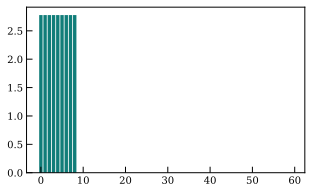

In [7]:
# eigen values of initial cov
dX_0 = X_0 - X_0.mean(axis=0, keepdims=True)
P_0 = dX_0.T @ (dX_0) / (m-1)

plt.bar(np.arange(J), sorted(np.linalg.eigvals(P_0), reverse=True))
print(min(np.linalg.eigvals(P_0)))

In [29]:
# Spatio-temporal Plot

# t_start = 0
# t_end = 500
# x1 = x_true[t_start:t_end]
# y_extend = (H.T@y[t_start:t_end].T).T # embed y into state space: (T, Ny) -> (T, Nx)
# y_mask = np.ma.masked_where(y_extend==0.0, y_extend)
# x2 = y_mask
# x3 = x_assim[t_start:t_end]
# x4 = x_assim_alpha[t_start:t_end]

# vmax = np.max(x1)
# vmin = np.min(x1)
# fig, ax = plt.subplots(1, 4, figsize=(3*4, 3))
# im = ax[0].imshow(x1, aspect=J/(t_end-t_start), vmax=vmax, vmin=vmin, origin="lower", interpolation="none")
# ax[0].set_ylabel("time")
# ax[0].set_xlabel("i")
# ax[0].set_title("x_true")

# ax[1].imshow(x2, aspect=J/(t_end-t_start), vmax=vmax, vmin=vmin, origin="lower", interpolation="none")
# ax[1].set_xlabel("i")
# ax[1].set_title("y_obs")
# ax[1].set_yticks([])

# ax[2].imshow(x3, aspect=J/(t_end-t_start), vmax=vmax, vmin=vmin, origin="lower", interpolation="none")
# ax[2].set_xlabel("i")
# ax[2].set_title("x_esti($\\alpha=1.0$)")
# ax[2].set_yticks([])

# ax[3].imshow(x4, aspect=J/(t_end-t_start), vmax=vmax, vmin=vmin, origin="lower", interpolation="none")
# ax[3].set_xlabel("i")
# ax[3].set_title("x_esti($\\alpha=1.2$)")
# ax[3].set_yticks([])

# cax = fig.add_axes([0.92, 0.155, 0.015, 0.675])

# fig.colorbar(im, cax=cax)
# fig.suptitle(f"spatio-temporal plot: from t={t_start} to t={t_end}")

## Run DA over $\alpha$

In [10]:
import scipy as sp
from tqdm import tqdm
# alpha_list = [1.0, 1.1, 5.0] # for multiplicative inflation
# alpha_list = [0.0, 0.5, 1.0, 1.5, 2.0] # for additive inflation
alpha_list = [0.0, r/16, r/8, r/4, r/2, r, 2*r, 4*r] # for additive inflation
seed_list = np.arange(1)
method = "po_add"

paramname = f"m({m})-{method}-alpha({'='.join([str(alpha) for alpha in alpha_list])})-seeds({len(seed_list)})"
try:
    # raise
    Xa = np.load(f"{data_dir}/xa-{paramname}.npy")
    print("Xa loaded:", Xa.shape)
    # evals_alpha = np.load(f"{data_dir}/evals_alpha-{paramname}.npy")
except:
    # evals_alpha = np.zeros((len(alpha_list), len(seed_list), Nt, J))
    Xa = np.zeros((len(alpha_list), len(seed_list), Nt, m, J))
    # Y = np.zeros((len(seed_list), Nt, H.shape[0]))
    for i, alpha in enumerate(alpha_list):
        print("alpha:", alpha)
        for j, seed in enumerate(seed_list):
            # random seed
            np.random.seed(seed)

            # generate observation
            # 効率が悪い
            y = (H@x_true.T).T
            y += np.random.multivariate_normal(mean=np.zeros_like(y[0]), cov=R, size=len(y))
            # y = (H@y.T).T # yを埋め込んでいなければ必要ない
            # if i == 0:
            #     Y[j] = y
            
            # run da
            # set DA method
            if method == "etkf":
                da_instance = ETKF(M, H, R, alpha=alpha**2, store_ensemble=True)
            elif method == "po_add":
                da_instance = PO(M, H, R, alpha=alpha**2, store_ensemble=True, additive_inflation=True)
            elif method == "po_proj":
                da_instance = PO(M, H, R, alpha=alpha**2, store_ensemble=True, additive_inflation=True, project_cov=True)
            # elif method == "po_multi":
            #     da_instance = PO(M, H, R, alpha=alpha**2, store_ensemble=True, additive_inflation=False)
            else:
                raise
            
            # initialize ensemble
            da_instance.initialize(X_0)
            for y_obs in tqdm(y):
                da_instance.forecast(Dt)
                da_instance.update(y_obs)

            Xa[i, j] = da_instance.Xa

            # Compute evalues
            # TODO: SVD(dX/sqrt(m-1))の計算に修正
            # Pf = []
            # for X in da_instance.Xf: # X_fとXfの違いに注意
            #     m = X.shape[0]
            #     dX = X - X.mean(axis=0, keepdims=True)
            #     P = dX.T @ (dX) / (m-1)
            #     Pf.append(P)
            # evals = np.array([sorted(sp.linalg.eigvals(Pf_t).real, reverse=True) for Pf_t in Pf])
            # evals_alpha[i, j] = evals

    np.save(f"{data_dir}/xa-{paramname}", Xa)
    # np.save(f"{data_dir}/evals_alpha-{method}-{paramname}", evals_alpha)

Xa loaded: (8, 1, 7200, 10, 60)


## Theoretical error bound
For each time, let $ \bar{v}, u \in \mathbb{R}^J $ be the analysis mean and true state respectively.
### SE(Square Error)
$$ \text{SE} = \sum_{i=1}^J |\bar{v}^i - u^i|^2 $$
- full-observation
  - PO: `2Jr^2` $ \sim $ observarion SE ($ 2m\gamma^2 $ in the paper).

$$ \text{SE}_H = \|\delta\|_H^2 = \sum_{i=1}^J |\bar{v}^i - u^i|^2 + |H(\bar{v}^i - u^i)|^2 $$

$$ \|\delta^{(k)}\|^2 = \sum_{i=1}^J |(v^{(k)})^i - u^i|^2 + |H((v^{(k)})^i - u^i)|^2 $$

- partial observation
  - PO: `8/3 Jr^2 = 4 Ny r^2`

##### ※RMSE(Root Mean Square Error)
$ \text{RMSE} = \left(\frac{1}{J} \sum_{i=1}^J |\bar{v}^i - u^i|^2\right)^{1/2} $, theoretical bound of RMSE: `r` $ \approx $ observarion RMSE ($ \gamma $ in the paper).

## Plot errors and minimum eigenvalues

In [9]:
def loss_sq(X, Y):
    """
    X, Y: (Nt, J)
    """
    return np.sum((X-Y)**2, axis=-1)


def stats(X):
    """
    X: (N_seed, Nt)
    """
    return X.mean(axis=0), X.std(axis=0)

load file
['po_add']
m(10)-po_add-alpha(0.0=0.000625=0.00125=0.0025=0.005=0.01=0.02=0.04)-seeds(1)
t-averaged SE 2464.0861010253075
t-averaged SE 1726.1537440481766
t-averaged SE 343.85234288825984
t-averaged SE 0.0009893754602432418
t-averaged SE 0.0024413512509146433
t-averaged SE 0.006357613921920105
t-averaged SE 0.011611787662323948
t-averaged SE 0.014947093661324778


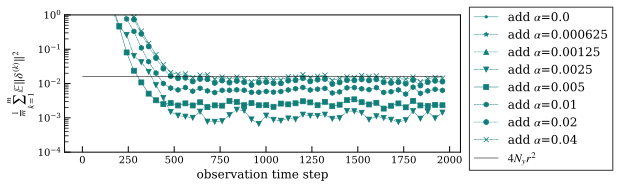

In [14]:
from visualize import get_color_palette, get_linestyle_cycle, get_marker_cycle

# obs noise impact dimension
Ny = np.linalg.matrix_rank(H)


# methods
# methods = ["po_proj"]
methods = ["po_add"]
# methods = ["po_add", "po_proj"]

# Plot
per_vis = 40 # NOTE: plot SE mean over Nseed realizations per {per_vis} time steps (1time step:6h)
per_ticklabel = per_vis * 20

N_end = 50 # NOTE: plot til N_end steps

lw = 0.5
# --------------

# load data
print("load file")
print(methods)
# xa_alpha = np.load(f"{data_dir}/xa_alpha-{paramname}.npy")
# evals_alpha = np.load(f"{data_dir}/evals_alpha-{method}-{paramname}.npy")

fig1, ax1 = plt.subplots(figsize=(7,3))
# fig2, ax2 = plt.subplots(figsize=(10.2,3))

num_alpha = len(alpha_list)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

time_ticks = np.arange(Nt//per_vis)*per_vis + 1
time_ticklabels = np.arange(Nt//per_ticklabel+1)*per_ticklabel
time_ticklabels[0] = 1


for k, method in enumerate(methods):
    paramname = f"m({m})-{method}-alpha({'='.join([str(alpha) for alpha in alpha_list])})-seeds({len(seed_list)})"
    print(paramname)
    Xa = np.load(f"{data_dir}/xa-{paramname}.npy")

    color = colors[k]
    line_cycle = get_linestyle_cycle()
    marker_cycle = get_marker_cycle()

    for i, xa in enumerate(Xa):
        alpha = alpha_list[i]
        # if i in [2, 3]:
        #     print("skip alpha:", alpha)
        #     continue

        # set plot vars
        ls = next(line_cycle)
        marker = next(marker_cycle)

        # compute SE stats
        se_wtm = loss_sq(x_true[None, :, None, :] - xa, 0) + loss_sq(x_true[None, :, None, :] @ H.T - xa @ H.T, 0) # (Nseed, Nt, m)
        se_tm, _ = stats(se_wtm) # (Nt, m); take the expectation E[]
        se_t = se_tm.mean(axis=1) # (Nt, ); take the ensemble mean
        se_wt = se_wtm.mean(axis=2) # (Nseed, Nt)
        print("t-averaged SE", se_tm[1000:].mean()) # time average of SE after spin-up (100 obs. steps)


        # plot RMSE of analysis
        ax1.plot(time_ticks[:N_end], se_t[::per_vis][:N_end], label=f"{method.replace('po_', '')} $\\alpha$={alpha}", lw=lw, ls=ls, color=color, marker=marker, ms=5)
        for se_k in se_wt:
            ax1.plot(time_ticks[:N_end], se_k[::per_vis][:N_end], lw=lw/2, color=color, alpha=0.2)
        

# observation noise std
ax1.plot(time_ticks[:N_end], 4*Ny*(r**2)*np.ones_like(time_ticks[:N_end]), label='$ 4 N_y r^2 $', lw=lw, c="black")

ax1.set_xlabel("observation time step")
# ax1.set_xticks([])
ax1.set_ylabel(r"$ \frac{1}{m} \sum_{k=1}^m \mathbb{E} \|\delta^{(k)}\|^2 $")
ax1.set_yscale("log")
ax1.set_ylim([r/100, 1])
fig1.tight_layout()
ax1.legend(bbox_to_anchor=(1.4, 1.1), loc='upper right')

# save fig
fig1.savefig(f"{data_dir}/l96-po-inflation_Pse.pdf", transparent=True)

## RMSE vs. alpha

load file
['po_add']
m(10)-po_add-alpha(0.0=0.000625=0.00125=0.0025=0.005=0.01=0.02=0.04)-seeds(1)


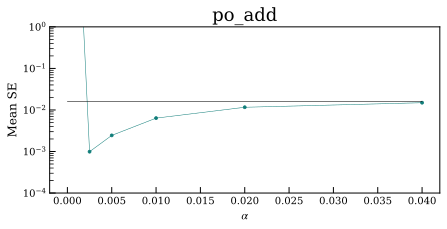

In [15]:
from visualize import get_color_palette, get_linestyle_cycle, get_marker_cycle

# obs noise impact dimension
Ny = np.linalg.matrix_rank(H)


# methods
# methods = ["po_proj"]
methods = ["po_add"]
# methods = ["po_add", "po_proj"]

# Plot
per_vis = 40 # NOTE: plot SE mean over Nseed realizations per {per_vis} time steps (1time step:6h)
per_ticklabel = per_vis * 20

N_end = 50 # NOTE: plot til N_end steps

lw = 0.5
# --------------

# load data
print("load file")
print(methods)

fig1, ax1 = plt.subplots(figsize=(7,3))
# fig2, ax2 = plt.subplots(figsize=(10.2,3))

num_alpha = len(alpha_list)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

time_ticks = np.arange(Nt//per_vis)*per_vis + 1
time_ticklabels = np.arange(Nt//per_ticklabel+1)*per_ticklabel
time_ticklabels[0] = 1


for k, method in enumerate(methods):
    paramname = f"m({m})-{method}-alpha({'='.join([str(alpha) for alpha in alpha_list])})-seeds({len(seed_list)})"
    print(paramname)
    Xa = np.load(f"{data_dir}/xa-{paramname}.npy")

    color = colors[k]
    line_cycle = get_linestyle_cycle()
    marker_cycle = get_marker_cycle()
    
    se_awtm = loss_sq(x_true[None, None, :, None, :] - Xa, 0) + loss_sq(x_true[None, None, :, None, :] @ H.T - Xa @ H.T, 0) # (Nseed, Nt, m)
    
    ax1.plot(alpha_list, se_awtm[:, :, 1000:].mean(axis=-1).mean(axis=-1).mean(axis=-1), marker="o")
    ax1.plot(alpha_list, 4*Ny*(r**2)*np.ones_like(alpha_list), label='$ 4 N_y r^2 $', lw=lw, c="black")
    ax1.set_yscale("log")
    # ax1.set_xscale("log")
    ax1.set_ylim([r/100, 1.0])
    ax1.set_ylabel("Mean SE")
    ax1.set_xlabel("$\\alpha$")
    ax1.set_title(method)